# 02 · Modelling on real data

Trains the project's **leak-free pipeline** (`model.build_pipeline`) on the real
Ames sales and evaluates it with **5-fold cross-validation**, comparing:

1. a **baseline** that always predicts the median price,
2. the **project-default** XGBoost model,
3. a **lightly tuned** XGBoost model.

We also look at feature importance, SHAP contributions and residuals.

> `scripts/benchmark_real_data.py` runs the same benchmark headlessly and writes
> `reports/real_data_benchmark.md`.

In [1]:
import os, sys
for _candidate in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.exists(os.path.join(_candidate, "config.py")) and _candidate not in sys.path:
        sys.path.insert(0, _candidate)

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import real_data
import model as model_lib
import config
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline

df = real_data.load_real_data()
X = df[config.FEATURE_COLUMNS]
y = df[config.TARGET_COLUMN]
print("records:", len(df), "| neighbourhoods:", df["neighborhood"].nunique())

records: 1460 | neighbourhoods: 25


## Cross-validated comparison

Metrics are mean over 5 folds on the **real** sales.

In [2]:
base = real_data.cross_validate_metrics(
    Pipeline([("model", DummyRegressor(strategy="median"))]), X, y
)
current = real_data.cross_validate_metrics(model_lib.build_pipeline(), X, y)

table = pd.DataFrame({
    "Baseline (median)": base["mean"].round(3),
    "XGBoost (defaults)": current["mean"].round(3),
})
table

,Baseline (median),XGBoost (defaults)
metric,,
mae,55655.519,20367.044
rmse,81275.322,32227.787
mape,31.805,12.061
r2,-0.054,0.820


### Light tuning

A small `RandomizedSearchCV` over the main tree hyper-parameters.

In [3]:
tuned, best_params = real_data.tune_model(X, y, n_iter=12, cv=3)
tuned_cv = real_data.cross_validate_metrics(tuned, X, y)

table["XGBoost (tuned)"] = tuned_cv["mean"].round(3)
best_params

{'regressor__model__subsample': 0.7,
 'regressor__model__n_estimators': 700,
 'regressor__model__min_child_weight': 1,
 'regressor__model__max_depth': 4,
 'regressor__model__learning_rate': 0.02,
 'regressor__model__colsample_bytree': 1.0}

In [4]:
# Pretty summary (dollars / percent)
summary = pd.DataFrame({
    "MAE ($)": table.loc["mae"].round(0).astype(int),
    "RMSE ($)": table.loc["rmse"].round(0).astype(int),
    "MAPE (%)": table.loc["mape"].round(1),
    "R²": table.loc["r2"].round(3),
})
summary

,MAE ($),RMSE ($),MAPE (%),R²
Baseline (median),55656,81275,31.8,-0.054
XGBoost (defaults),20367,32228,12.1,0.820
XGBoost (tuned),20567,32564,12.2,0.820


## Feature importance (gain, aggregated to base features)

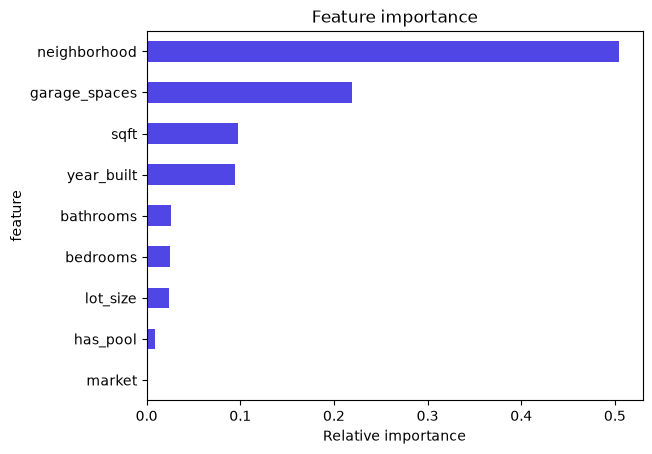

In [5]:
fitted = model_lib.build_pipeline()
fitted.fit(X, y)
importance = model_lib.get_feature_importance(fitted)
importance.sort_values("importance").plot(
    kind="barh", x="feature", y="importance", legend=False, color=config.COLORS["primary"]
)
plt.title("Feature importance")
plt.xlabel("Relative importance")
plt.show()

## SHAP contributions

Using XGBoost's built-in `pred_contribs` (no extra dependency).

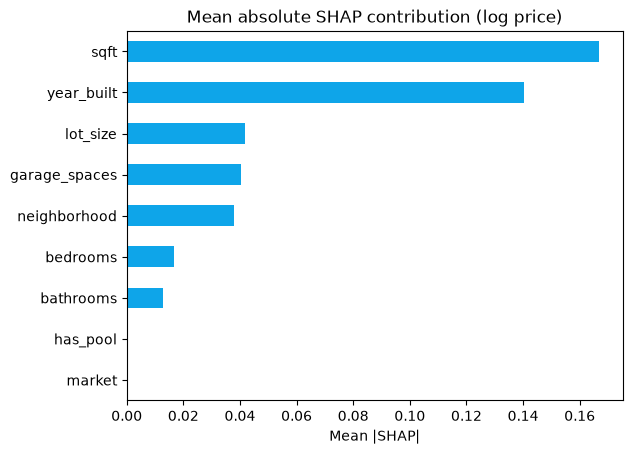

In [6]:
import xgboost as xgb

pre = fitted.regressor_.named_steps["preprocessor"]
est = fitted.regressor_.named_steps["model"]
X_trans = pre.transform(X)
contribs = est.get_booster().predict(xgb.DMatrix(X_trans), pred_contribs=True)
names = [model_lib._base_feature(n) for n in pre.get_feature_names_out()]
shap_df = pd.DataFrame(contribs[:, :-1], columns=names).T.groupby(level=0).sum().T

mean_abs = shap_df.abs().mean().sort_values()
mean_abs.plot(kind="barh", color=config.COLORS["accent"])
plt.title("Mean absolute SHAP contribution (log price)")
plt.xlabel("Mean |SHAP|")
plt.show()

## Residuals (on the training set, for shape)

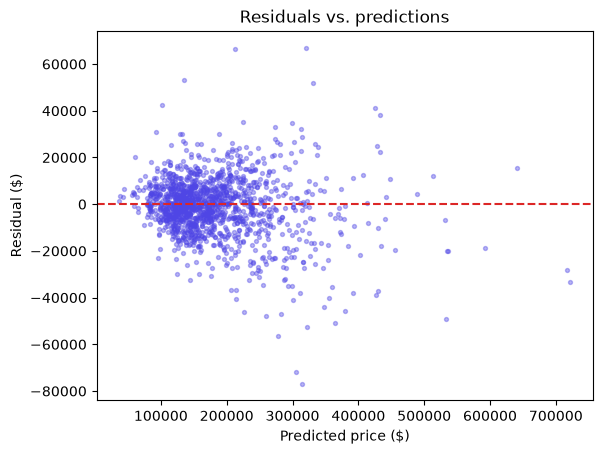

In [7]:
pred = fitted.predict(X)
resid = pred - y
plt.scatter(pred, resid, s=8, alpha=0.4, color=config.COLORS["primary"])
plt.axhline(0, color=config.COLORS["danger"], linestyle="--")
plt.xlabel("Predicted price ($)")
plt.ylabel("Residual ($)")
plt.title("Residuals vs. predictions")
plt.show()

## Conclusions

- The pipeline improves massively over the median baseline on **real** sales
  (MAE ≈ $20k vs ≈ $56k, R² ≈ 0.82).
- Neighbourhood and size dominate, consistent with the EDA.
- Tuning gives a small but real improvement.

**Caveat:** Ames is a single, static city dataset. It validates the modelling
*approach*; the shipped dashboard still uses synthetic listings calibrated to
real Zillow medians (see `docs/MODEL_CARD.md`).